In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


In [4]:
df = pd.read_csv("cleaned_flights_dataset__.csv")

In [5]:
# Create delay flag (industry standard >15 mins)
df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15

# Recreate DAY_NAME
df['DAY_NAME'] = df['DAY_OF_WEEK'].map({
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
})

# Create ROUTE column (if not present)
df["ROUTE"] = df["ORIGIN_AIRPORT"] + " → " + df["DESTINATION_AIRPORT"]

# Create departure hour
df["SCHEDULED_DEPARTURE"] = df["SCHEDULED_DEPARTURE"].astype(str).str.zfill(4)
df["DEPARTURE_HOUR"] = df["SCHEDULED_DEPARTURE"].str[:2].astype(int)

## Visualization 1: Top Airlines by Flight Volume

This bar chart shows which airlines operate the highest number of flights. 
It helps identify the busiest carriers in the dataset.

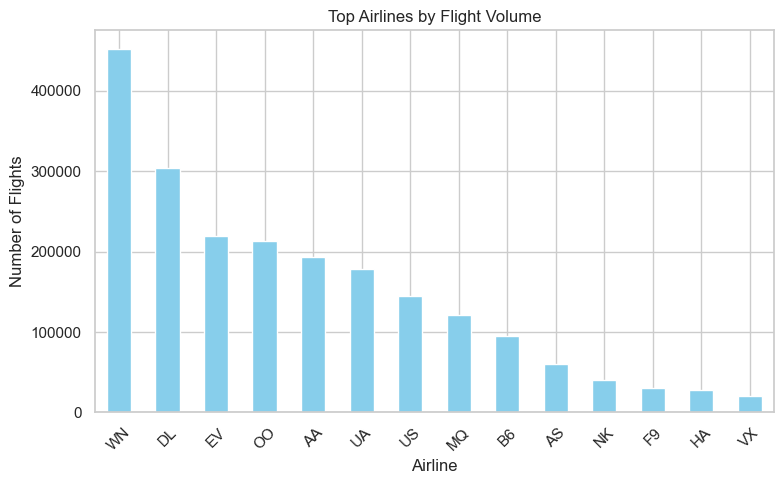

In [6]:
import matplotlib.pyplot as plt

# Count flights per airline
airline_counts = df["AIRLINE"].value_counts()

plt.figure(figsize=(8,5))
airline_counts.plot(kind="bar", color="skyblue")

plt.title("Top Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Visualization 2: Top 10 Busiest Routes

This chart shows the top 10 most frequently operated routes 
(Origin → Destination). It highlights high-traffic corridors.

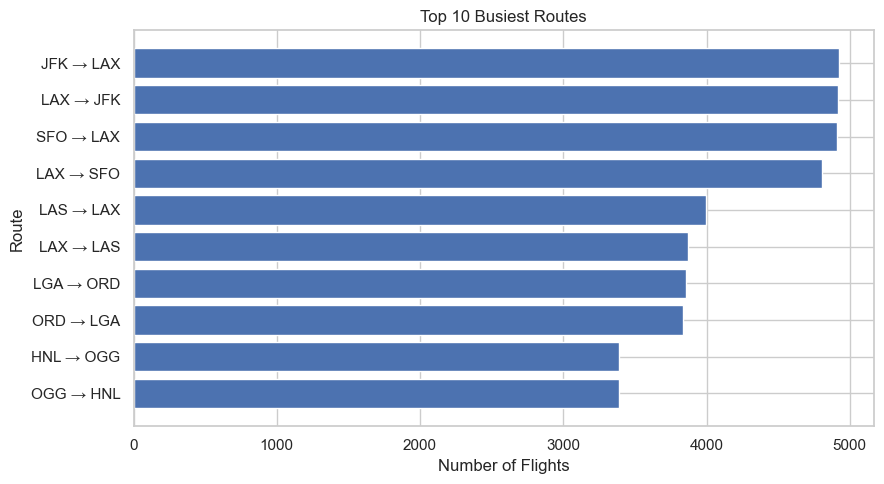

In [7]:
import matplotlib.pyplot as plt

# Get Top 10 busiest routes
top_routes = df["ROUTE"].value_counts().head(10).sort_values()

plt.figure(figsize=(9,5))
plt.barh(top_routes.index, top_routes.values)

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

## Visualization 3: Monthly Flight Volume

This area chart shows the total number of flights operated each month.  
It helps identify seasonal trends and peak travel periods.

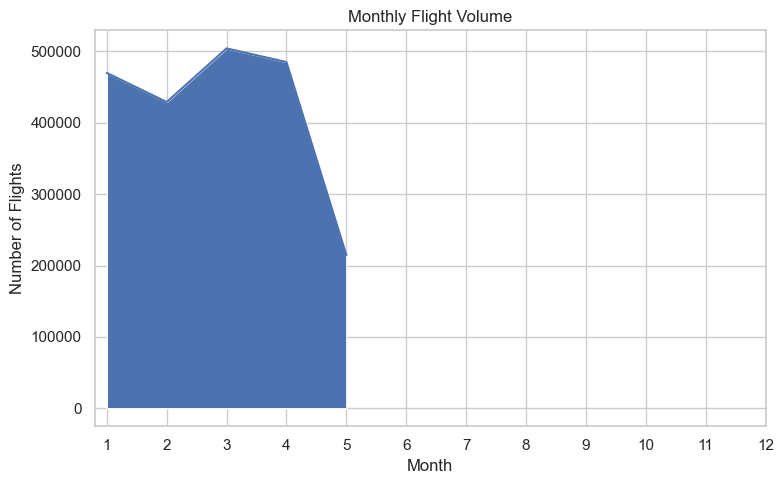

In [8]:
import matplotlib.pyplot as plt

# Count flights per month
monthly_counts = df.groupby("MONTH")["FLIGHT_NUMBER"].count()

plt.figure(figsize=(8,5))

plt.fill_between(monthly_counts.index, monthly_counts.values)
plt.plot(monthly_counts.index, monthly_counts.values)

plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

## Visualization 4: Flight Volume by Day of Week

This donut chart shows how flights are distributed across the week.  
It helps identify the busiest and least busy days.

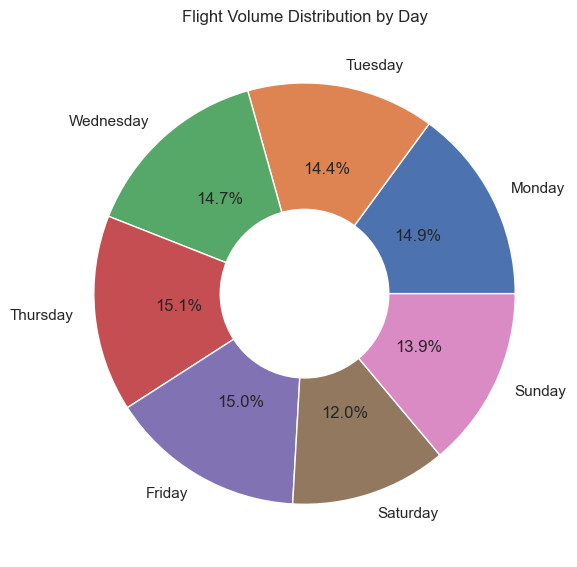

In [9]:
import matplotlib.pyplot as plt

# Ensure correct weekday order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

weekly_counts = df["DAY_NAME"].value_counts().reindex(day_order)

plt.figure(figsize=(6,6))

# Donut chart
plt.pie(weekly_counts.values, labels=weekly_counts.index, autopct="%1.1f%%")
plt.gca().add_artist(plt.Circle((0,0), 0.40, fc="white"))

plt.title("Flight Volume Distribution by Day")

plt.tight_layout()
plt.show()

## Visualization 5: Flight Volume by Departure Hour

This histogram shows how flight departures are distributed across 
different hours of the day. It helps identify peak operating hours.

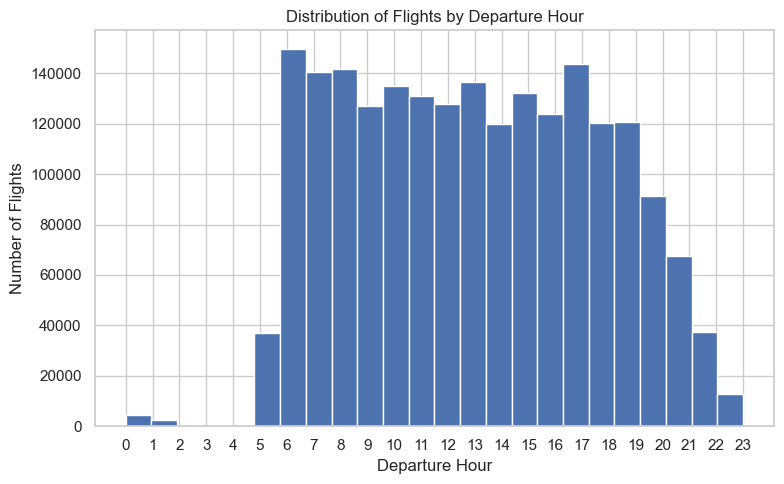

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["DEPARTURE_HOUR"], bins=24)

plt.title("Distribution of Flights by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")

plt.xticks(range(0,24))

plt.tight_layout()
plt.show()

## Visualization 6: Top 10 Busiest Origin Airports

This treemap shows the top 10 airports with the highest number of 
departing flights. The size of each block represents flight volume.

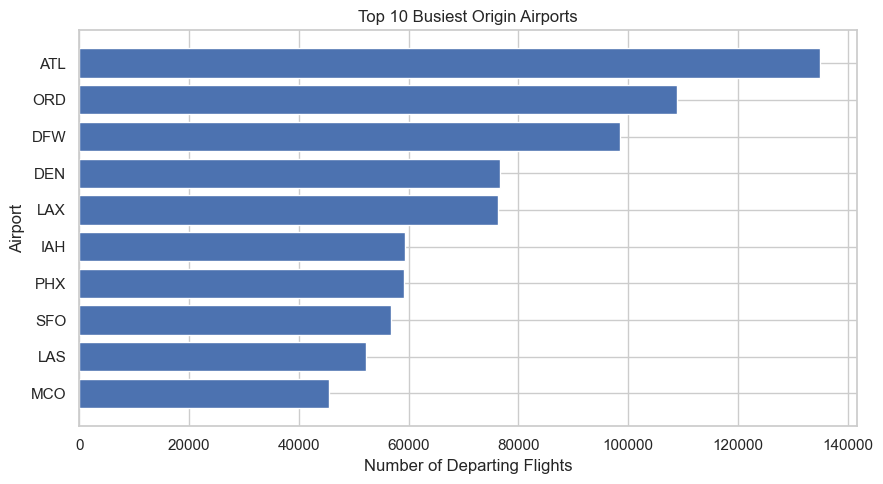

In [14]:
import matplotlib.pyplot as plt

# Get Top 10 busiest origin airports
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10).sort_values()

plt.figure(figsize=(9,5))
plt.barh(top_airports.index, top_airports.values)

plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Number of Departing Flights")
plt.ylabel("Airport")

plt.tight_layout()
plt.show()

## Visualization 7: Delay Distribution by Airline

This boxplot shows the distribution of arrival delays for each airline.  
It helps identify airlines with higher variability and extreme delays.

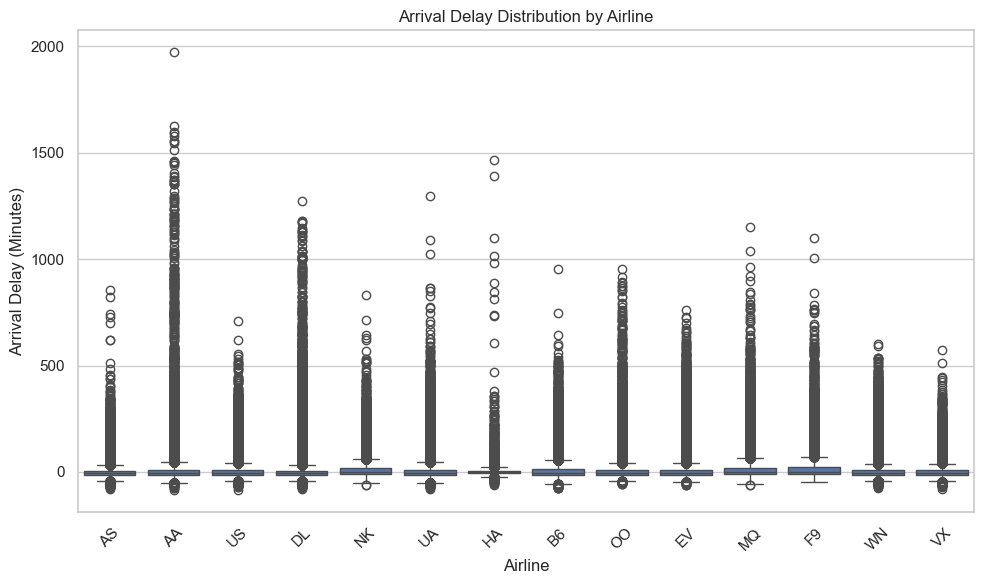

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    x="AIRLINE",
    y="ARRIVAL_DELAY",
    data=df
)

plt.title("Arrival Delay Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Arrival Delay (Minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Visualization 8: Average Delay Minutes by Cause per Airline
This grouped bar chart compares the average delay minutes by cause across airlines.

<Figure size 1200x600 with 0 Axes>

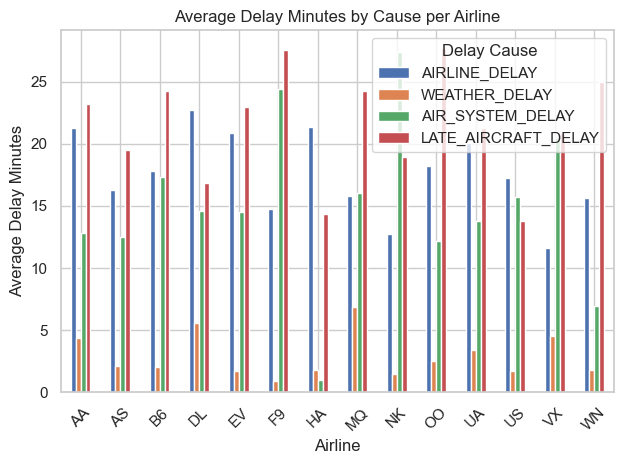

In [29]:
# Calculate mean delay causes per airline
delay_causes = df.groupby("AIRLINE")[[
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "AIR_SYSTEM_DELAY",
    "LATE_AIRCRAFT_DELAY"
]].mean()

plt.figure(figsize=(12,6))
delay_causes.plot(kind="bar")

plt.title("Average Delay Minutes by Cause per Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay Minutes")
plt.xticks(rotation=45)
plt.legend(title="Delay Cause")
plt.tight_layout()
plt.show()

## Visualization 9: Delay Rate by Departure Hour

This line chart shows how delay rates vary across different hours of the day.  
It helps identify peak delay periods.

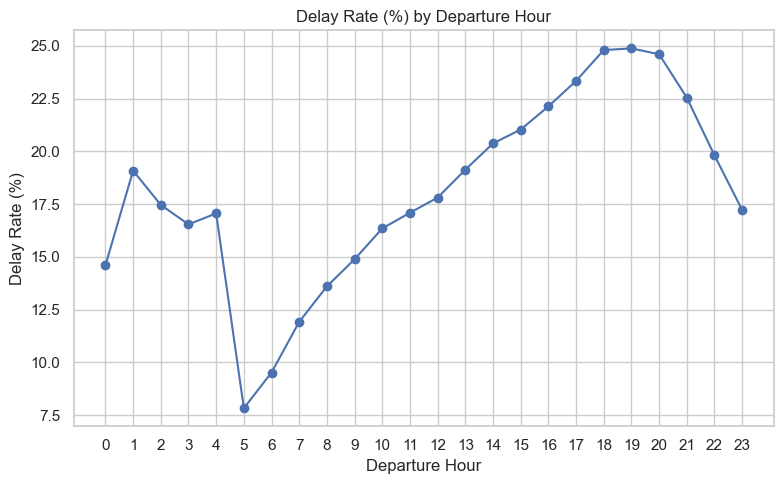

In [16]:
import matplotlib.pyplot as plt

# Calculate delay rate by hour
hourly_delay = df.groupby("DEPARTURE_HOUR")["IS_DELAYED"].mean() * 100

plt.figure(figsize=(8,5))

plt.plot(hourly_delay.index, hourly_delay.values, marker="o")

plt.title("Delay Rate (%) by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(0,24))

plt.tight_layout()
plt.show()

## Visualization 10: Delay Rate by Airport and Month

This heatmap shows how delay rates vary across airports and months.  
Darker colors indicate higher delay rates.

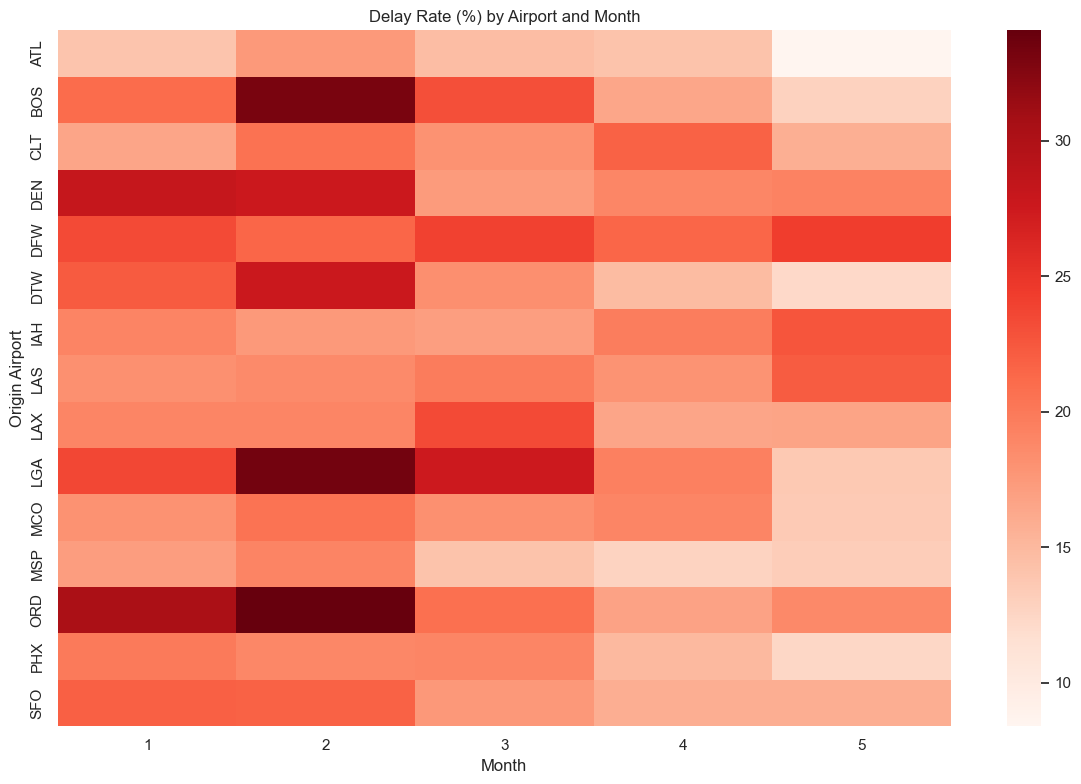

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select Top 15 busiest airports
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(15).index
df_top = df[df["ORIGIN_AIRPORT"].isin(top_airports)]

# Create pivot table
heatmap_data = (
    df_top.groupby(["ORIGIN_AIRPORT", "MONTH"])["IS_DELAYED"]
    .mean()
    .unstack() * 100
)

plt.figure(figsize=(12,8))

sns.heatmap(heatmap_data, cmap="Reds")

plt.title("Delay Rate (%) by Airport and Month")
plt.xlabel("Month")
plt.ylabel("Origin Airport")

plt.tight_layout()
plt.show()

## Visualization 11: Overall Delay Cause Contribution
This visualization shows the total contribution of each delay type across all flights.

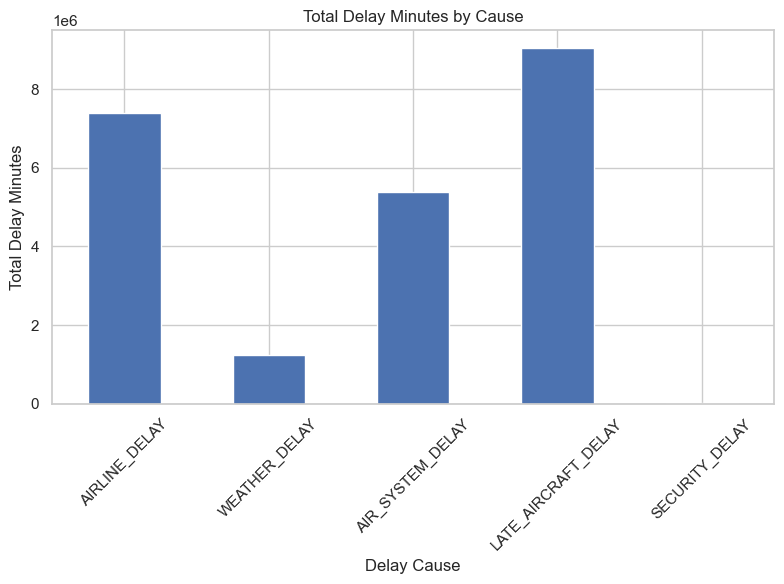

In [32]:
# Calculate total delay minutes by cause
total_delay_causes = df[[
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "AIR_SYSTEM_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "SECURITY_DELAY"
]].sum()

plt.figure(figsize=(8,6))
total_delay_causes.plot(kind="bar")

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()